In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import torch
from tailnflows.utils import load_raw_data, load_experiment_output_data, get_data_path
from tailnflows.targets.data import real_data_sources

In [2]:
# Load experiment results
data_source = 'insurance'
experiment_name = '2026-09-14-de-insurance'
experiment_output = load_experiment_output_data(f'{data_source}/{experiment_name}/results')

# Put experiment results in dataframe
rows = []
for model, run_datas in experiment_output.items():
    for rd in run_datas:
        rows.append({
            'data': model.split('-')[0],
            **rd
        })

df = pd.DataFrame(rows)

# convert tensor columns to float if necessary (for old experiment data)
for metric in ['var99_ht', 'var99_lt', 'var995_ht', 'var995_lt', 'var999_ht', 'var999_lt']:
    df[metric] = df[metric].apply(lambda x: x.item())

In [3]:
grouper = ['model', 'depth']

# select only experiments with specific parameters
selector = np.ones(len(df), dtype=bool)
df = df[selector]

# aggregate nll results over splits
grouped = df.groupby(grouper)
agg = grouped[['val_nll', 'tst_nll', 'sw2', 'w1_ht', 'w1_lt', 'var99_ht', 'var99_lt', 'var995_ht', 'var995_lt', 'var999_ht', 'var999_lt']].agg(['mean', 'sem', 'std'])
# print(agg)

# Select best test nll results and its std
best = agg['var99_ht'].sort_values(by='mean') # type: ignore
within = best.iloc[0]['mean'] + 1.0 * best.iloc[0]['std']

def highlight_by_mean(row, threshold=7):
    """
    Highlight the row if the 'Mean' value is below the given threshold.
    """
    if row['mean'] < threshold:
        # Highlight entire row in a light green
        return ['background-color: #dfffdf'] * len(row) # light-green
    else:
        # No highlight
        return ['background-color: white'] * len(row)

# Show sorted results
best.style.apply(
    highlight_by_mean, 
    axis=1, 
    threshold=within
)

,,mean,sem,std
model,depth,,,
ttf_hdonly,1,0.176049,0.071651,0.226581
ttf_lin_hdonly,1,0.316365,0.111570,0.352816
ttf_qua_hdonly,1,0.320748,0.110295,0.348782
ttf_erfi_hdonly,1,0.340943,0.095769,0.302848
softlog_lin_hdonly,1,0.447072,0.153264,0.484662
softlog_hdonly,1,0.451917,0.166157,0.525433
arcsinh_lin_hdonly,1,0.490020,0.171933,0.543700
arcsinh_hdonly,1,0.536253,0.220156,0.696195
normal,1,0.680925,0.335860,1.062081


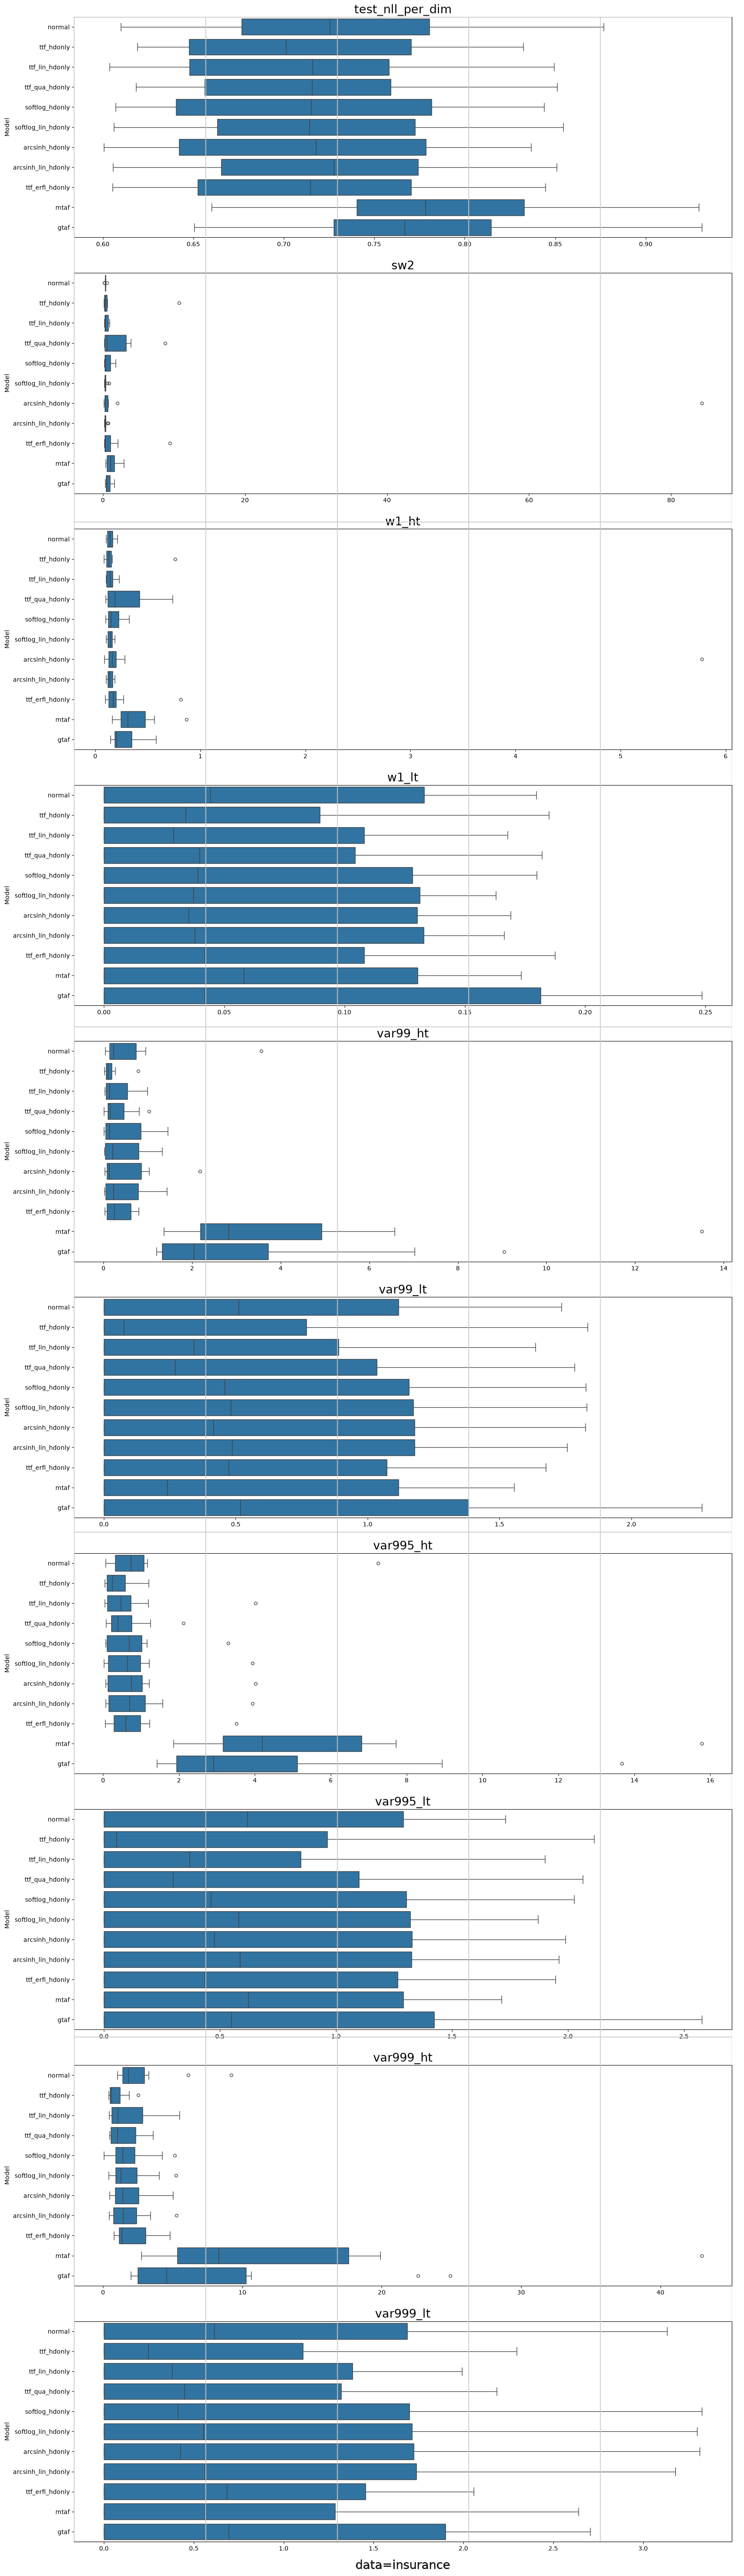

In [4]:
# Plot metrics boxplots

# Add test NLL/dim as column
df['test_nll_per_dim'] = df['tst_nll'] / df['dim']
df.head()

metrics = ['test_nll_per_dim', 'sw2', 'w1_ht', 'w1_lt', 'var99_ht', 'var99_lt', 'var995_ht', 'var995_lt', 'var999_ht', 'var999_lt']

fig, axarr = plt.subplots(len(metrics), 1, figsize=(18, 6*len(metrics)), tight_layout=True, sharey=True)
if len(metrics) == 1:
  axarr = [axarr]

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=2.)

for i, metric in enumerate(metrics):
  j = 1

  sns.boxplot(
      data=df,
      x=metric,
      y='model',
      orient='h',
      ax=axarr[i],
  )

  axarr[i].set_title(metric)
  axarr[i].set_xlabel('')
  axarr[i].set_ylabel('Model')

  fig.add_subplot(111, frameon=False)
  plt.xlabel(f'data={data_source}')
  plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
  plt.tight_layout()
  # plt.savefig(f"./real_sp500.png")

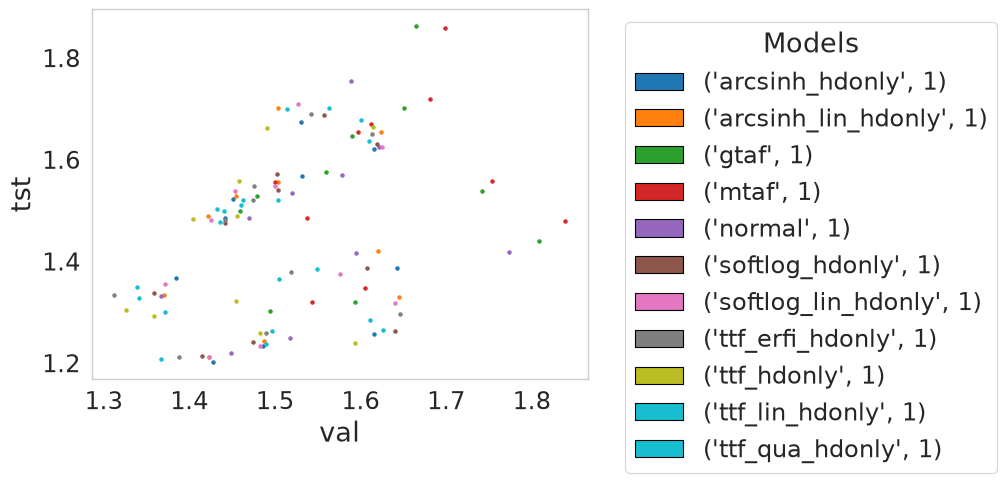

In [5]:
# Plot final test nll against final validation nll for all models (lower test nll is better)!

color_palette = plt.get_cmap('tab10', len(agg.index))  # Using a colormap
model_to_color = {model: color_palette(i) for i, model in enumerate(agg.index)}

selected_ix = []
for ix, group in grouped:
    plt.scatter(group.val_nll, group.tst_nll, color=model_to_color[ix], marker='.')
    # plt.scatter(ix[-2], group.tst_ll, c=model_to_color[ix])
    ix = (ix[0], int(ix[1]))
    selected_ix.append(ix)

plt.ylabel('tst')
plt.xlabel('val')
legend_elements = [Patch(facecolor=model_to_color[model], edgecolor='black', label=model) 
                   for model in selected_ix] # integer in the models legend represents depth parameter
plt.legend(handles=legend_elements, title="Models", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()

In [8]:
# plot statistics on random 1d projected datasets
from tailnflows.metrics.random_projections import plot_rand_proj_stats

split = 9

wanted_data = {}
for model, rd in experiment_output.items():
    if rd[0]['split'] == split:
        wanted_data[model] = rd

# Load synthetic samples
synth_samps = {model.split("-")[-1]: rd[0]["synth_samps"] for model, rd in wanted_data.items()}

# Load target samples
tail_path = f'{get_data_path()}/splits/{data_source}/{split}'
splits_and_tail = load_raw_data(tail_path)["experiment_data"][0]
metadata = splits_and_tail["metadata"]
if data_source == 'climate':
    x_tst = splits_and_tail["split"]["x_tst"]
else:
    x = real_data_sources[data_source]()
    tst_ix = splits_and_tail["split"]["tst"]
    mean = torch.tensor(metadata["mean"])
    scale = torch.tensor(metadata["std"])
    x_tst = (x[tst_ix] - mean) / scale
target_samps = x_tst.to(torch.float32)

plot_rand_proj_stats(target_samps, synth_samps, label=f"{experiment_name}_{data_source}_{split}")
print(f"Saved plots for {data_source} data split {split} in plots.")

Saved plots for insurance data split 9 in plots.


In [ ]:
# print evolution of train and val loss for all models
for label, runs in experiment_output.items():
    for run in runs:
        losses = load_raw_data(run['loss_path'])[label][
            run['loss_ix']
        ]

        plt.title(f'{label} lr={run["lr"]} | batch_size={run["batch_size"]}')
        l, = plt.plot(np.arange(len(losses['losses'])), losses['losses'], label='') # training losses
        plt.plot(losses['steps'], losses['vlosses'], linestyle='--', c=l.get_color()) # validation losses
        plt.xlabel('update steps')
    plt.grid()
    plt.show()

In [ ]:
# Inspect split data
data_source = "insurance"
split = 0
tail_path = f'{get_data_path()}/splits/{data_source}/{split}'
if not Path(f"{tail_path}.p").is_file():
    raise Exception(
        f"Split data not present at {tail_path}.p, either configure "
        "TAILNFLOWS_DATA_DIR, or run `python experiments/density_estimation_real_data/generate_splits.py`"
    )

splits_and_tail = load_raw_data(tail_path)["experiment_data"][0]
print(splits_and_tail)

metadata = splits_and_tail["metadata"]
# print("Metadata: ", metadata)
dfs = metadata["dfs"]
pos_dfs = metadata["pos_dfs"]
neg_dfs = metadata["neg_dfs"]
seed = metadata["seed"]
if data_source != "climate": # mean and std split data are not available for climate
    mean = metadata["mean"]
    std = metadata["std"]

print(f"Split data for {data_source} split {split}:")

if data_source != "climate":
    print(f"Mean: {[round(float(m), 2) for m in mean]}")
    print("len(mean): ", len(mean))
    print(f"Std: {[round(float(s), 2) for s in std]}")
print(f"Seed: {seed}")
print(f"dfs: {[round(df, 2) for df in dfs]}")
print(f"pos_dfs: {[round(df, 2) for df in pos_dfs]}")
print(f"neg_dfs: {[round(df, 2) for df in neg_dfs]}")

avg_df, std_df = np.mean(dfs), np.std(dfs)
avg_pos_df, std_pos_df = np.mean(pos_dfs), np.std(pos_dfs)
avg_neg_df, std_neg_df = np.mean(neg_dfs), np.std(neg_dfs)

print(f"Average df: {avg_df:.2f} ({std_df:.2f})")
print(f"Average pos df: {avg_pos_df:.2f} ({std_pos_df:.2f})")
print(f"Average neg df: {avg_neg_df:.2f} ({std_neg_df:.2f})")